<a href="https://colab.research.google.com/github/bigwisu/CITRUS-CAI-PDM/blob/main/CITRUS_CAI_PDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
# @title Mount Google Drive

from google.colab import drive
import os

drive.mount('/content/drive')

journal_title = "CANOPY"

file_path = f"/content/drive/MyDrive/DSM/Publication/{journal_title}/lit-repo"

Mounted at /content/drive


In [ ]:
# @title Definiton to Merge ScienceDirect BibTeX with Scopus CSV

!pip install -q bibtexparser

import pandas as pd
import numpy as np

def merge_and_deduplicate_dataframes(scopus_df: pd.DataFrame, sciencedirect_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merges and deduplicates Scopus and ScienceDirect DataFrames.

    Args:
        scopus_df (pd.DataFrame): DataFrame containing Scopus data.
        sciencedirect_df (pd.DataFrame): DataFrame containing ScienceDirect data.

    Returns:
        pd.DataFrame: A combined and deduplicated DataFrame.
    """

    # --- Prepare ScienceDirect DataFrame for merging ---

    # Make a copy to avoid modifying the original DataFrame directly if it's used elsewhere
    sd_df_processed = sciencedirect_df.copy()

    # Add 'database' column
    sd_df_processed['database'] = 'ScienceDirect'

    # Create 'norm_title' for sciencedirect_df (if not already present)
    if 'norm_title' not in sd_df_processed.columns:
        sd_df_processed['norm_title'] = sd_df_processed['title'].astype(str).str.lower().str.strip()

    # Standardize Source title: prioritize 'journal', then 'booktitle', then 'series'
    journal_col = sd_df_processed.get('journal', pd.Series(dtype=object))
    booktitle_col = sd_df_processed.get('booktitle', pd.Series(dtype=object))
    series_col = sd_df_processed.get('series', pd.Series(dtype=object))

    sd_df_processed['Source title'] = journal_col.fillna(booktitle_col).fillna(series_col)

    # Extract DOI from URL format
    if 'doi' in sd_df_processed.columns:
        sd_df_processed['doi'] = sd_df_processed['doi'].astype(str).str.replace('https://doi.org/', '', regex=False)

    # Extract Page start and Page end
    def parse_pages(pages_str):
        if pd.isna(pages_str):
            return np.nan, np.nan
        parts = str(pages_str).split('-')
        if len(parts) == 2:
            try:
                return float(parts[0]), float(parts[1])
            except ValueError:
                return np.nan, np.nan
        elif len(parts) == 1:
            try:
                return float(parts[0]), float(parts[0])
            except ValueError:
                return np.nan, np.nan
        return np.nan, np.nan

    sd_df_processed[['Page start', 'Page end']] = sd_df_processed['pages'].apply(lambda x: pd.Series(parse_pages(x)))

    # Map ENTRYTYPE to a more consistent format
    def map_document_type(entry_type):
        if pd.isna(entry_type): return np.nan
        entry_type = str(entry_type).lower()
        if 'article' in entry_type: return 'Article'
        if 'inproceedings' in entry_type or 'conference' in entry_type: return 'Conference Paper'
        if 'book' in entry_type: return 'Book'
        if 'chapter' in entry_type or 'incollection' in entry_type: return 'Book Chapter'
        return entry_type.title()

    sd_df_processed['Document Type'] = sd_df_processed['ENTRYTYPE'].apply(map_document_type)

    # Rename columns to match scopus_df
    sd_df_processed_renamed = sd_df_processed.rename(columns={
        'author': 'Authors',
        'title': 'Title',
        'abstract': 'Abstract',
        'year': 'Year',
        'doi': 'DOI',
        'url': 'Link',
        'volume': 'Volume',
        'number': 'Issue',
        'keywords': 'Author Keywords',
        'ID': 'EID'
    })

    # Add 'database' column to scopus_df (make a copy first)
    scopus_df_processed = scopus_df.copy()
    scopus_df_processed['database'] = 'Scopus'

    # Identify common columns and ensure their order
    # Start with Scopus columns as the reference structure
    scopus_cols_reference = scopus_df_processed.columns.tolist()

    # Define the columns that ScienceDirect should attempt to map to
    common_cols_potential = [
        'Authors', 'Title', 'Year', 'Source title', 'Volume', 'Issue',
        'Page start', 'Page end', 'DOI', 'Link', 'Abstract', 'Author Keywords',
        'Document Type', 'EID', 'norm_title', 'database'
    ]

    # Filter common_cols_potential to only include columns actually present in the processed ScienceDirect df
    sd_cols_present = [col for col in common_cols_potential if col in sd_df_processed_renamed.columns]

    # Select these columns from the renamed ScienceDirect df
    sd_df_final = sd_df_processed_renamed[sd_cols_present].copy()

    # Add any Scopus specific columns to sd_df_final with NaNs if they don't exist in SD data
    for col in scopus_cols_reference:
        if col not in sd_df_final.columns:
            sd_df_final[col] = np.nan

    # Reorder sd_df_final to match scopus_df_processed columns
    sd_df_final = sd_df_final[scopus_cols_reference]

    # --- Concatenate DataFrames ---
    combined_df = pd.concat([scopus_df_processed, sd_df_final], ignore_index=True)

    # --- Final Deduplication ---
    initial_combined_count = len(combined_df)

    if 'DOI' in combined_df.columns:
        combined_df = combined_df.drop_duplicates(subset=['DOI'], keep='first')
    if 'norm_title' in combined_df.columns:
        combined_df = combined_df.drop_duplicates(subset=['norm_title'], keep='first')

    final_combined_count = len(combined_df)

    print(f"Initial combined record count: {initial_combined_count}")
    print(f"Total duplicates removed after combining: {initial_combined_count - final_combined_count}")
    print(f"Final unique combined corpus: {final_combined_count}")

    return combined_df

In [ ]:
# @title Definition for APA 7 Citation generation

import pandas as pd

def format_authors_apa(author_string):
    """
    Formats a semicolon-separated author string into APA-style author list.
    Handles initials and 'et al.'.
    """
    if pd.isna(author_string) or not isinstance(author_string, str):
        return ""
    authors = [a.strip() for a in author_string.split(';') if a.strip()]
    if not authors:
        return ""

    formatted_names = []
    for author in authors:
        if author.lower() == 'et al.':
            formatted_names.append('et al.')
            continue

        parts = author.split(' ')
        if len(parts) > 1:
            last_name = parts[0]
            initials = "".join([f"{p[0]}." for p in parts[1:] if p])
            if initials:
                formatted_names.append(f"{last_name}, {initials}")
            else:
                formatted_names.append(last_name)
        else:
            formatted_names.append(author)

    if not formatted_names:
        return ""
    if len(formatted_names) == 1:
        return formatted_names[0]
    elif len(formatted_names) > 1:
        return f"{', '.join(formatted_names[:-1])}, & {formatted_names[-1]}"
    else:
        return ""


def generate_apa_citation(row):
    """
    Generates an APA 7 style citation string from a DataFrame row.
    """
    authors = format_authors_apa(row.get('Authors'))
    year = row.get('Year')
    title = row.get('Title')
    source_title = row.get('Source title')
    volume = row.get('Volume')
    issue = row.get('Issue')
    page_start = row.get('Page start')
    page_end = row.get('Page end')
    doi = row.get('DOI')
    link = row.get('Link')

    parts = []

    # 1. Authors and Year (e.g., Doe, J. (2020).)
    author_year_part = ""
    if authors:
        author_year_part += authors
    if year and pd.notna(year) and str(year).strip() != '':
        author_year_part += f" ({year})"
    if author_year_part:
        parts.append(author_year_part + ".")

    # 2. Title of article (e.g., The Impact of AI.)
    current_title = ""
    if title and pd.notna(title) and str(title).strip() != '':
        current_title = str(title).strip()

    # 3. Periodical information (e.g., *Journal of Research, 10*(2), 100-110.)
    periodical_info_string = ""
    periodical_elements = []
    # Removed markdown italics for Source title
    if source_title and pd.notna(source_title) and str(source_title).strip() != '':
        periodical_elements.append(f"{str(source_title).strip()}")

    volume_issue_pages_str = ""
    if volume and pd.notna(volume) and str(volume).strip() != '':
        volume_value = str(volume).strip()
        volume_issue_pages_str += f"{volume_value}"
        if issue and pd.notna(issue) and str(issue).strip() != '':
            issue_value = str(issue).strip()
            volume_issue_pages_str += f"({issue_value})"

    if page_start and pd.notna(page_start) and str(page_start).strip() != '':
        try:
            start_page = int(float(page_start)) if pd.to_numeric(page_start, errors='coerce') else str(page_start).strip()
        except ValueError:
            start_page = str(page_start).strip()

        if page_end and pd.notna(page_end) and str(page_end).strip() != '':
            try:
                end_page = int(float(page_end)) if pd.to_numeric(page_end, errors='coerce') else str(page_end).strip()
            except ValueError:
                end_page = str(page_end).strip()

            if start_page == end_page:
                volume_issue_pages_str += f", {start_page}"
            else:
                volume_issue_pages_str += f", {start_page}-{end_page}"
        else:
            volume_issue_pages_str += f", {start_page}"

    if volume_issue_pages_str:
        periodical_elements.append(volume_issue_pages_str)

    if periodical_elements:
        periodical_info_string = " ".join(periodical_elements)

    if current_title:
        # If there is periodical info, title does not end with a period in APA
        if periodical_info_string:
            parts.append(current_title)
        else:
            parts.append(current_title + ".") # Title gets a period if no periodical info

    if periodical_info_string:
        parts.append(periodical_info_string + ".") # Periodical info always ends with a period

    # 4. DOI or Link (e.g., https://doi.org/10.1000/182)
    doi_link_str = ""
    if doi and pd.notna(doi) and str(doi).strip() != '':
        doi_val = str(doi).strip()
        if not doi_val.startswith("http"):
            doi_link_str = f"https://doi.org/{doi_val}"
        else:
            doi_link_str = doi_val
    elif link and pd.notna(link) and str(link).strip() != '':
        doi_link_str = str(link).strip()

    if doi_link_str:
        parts.append(doi_link_str)

    citation_text = " ".join(filter(None, parts)).strip()

    # Final cleanup for edge cases: spaces before punctuation and double periods
    citation_text = citation_text.replace(" .", ".").replace(" ,", ",").replace(" (", "(").replace(" )", ")")
    citation_text = citation_text.replace("..", ".")

    return citation_text

In [ ]:
# @title Setup Gemini

# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

# Retrieve and process the API key from Colab's userdata secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY').split('\r\n')[0].strip()
genai.configure(api_key=GEMINI_API_KEY)

def call_gemini(prompt: str, model: str) -> str:
    """
    Calls the Gemini LLM with a given prompt and returns the text response.
    """
    # Initialize the Gemini-2.5-Flash-Lite model
    gemini_model = genai.GenerativeModel(model)

    try:
        response = gemini_model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Error calling LLM: {e}"


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
# @title Test PROMPT to confirm connection

PROMPT = "Confirm your connection to the LLM by saying 'Hello! Gemini is connected.'"

print("Testing LLM connection...")
llm_response = call_gemini(PROMPT,'gemini-flash-lite-latest')
print("LLM Response:")
print(llm_response)

Testing LLM connection...
LLM Response:
Hello! Gemini is connected.


# Lexical Search

In [ ]:
# @title Scopus

import pandas as pd
import os

# 1. Define File Sources (Explicitly specified by user)
single_scopus_file = "LEX-scopus_export_May-10-2026_1eea9c80.csv"
all_corpora_files = [single_scopus_file]

if not all_corpora_files:
    raise ValueError("No Scopus CSV files specified to process.")

print(f"Loading Scopus CSV Source: {all_corpora_files[0]}")

# 2. Build Independent Sets
def extract_dataframes(file_list):
    raw_df_list = []

    for file in file_list:
        try:
            # Construct the full file path
            full_path = os.path.join(file_path, file)
            df = pd.read_csv(full_path)
            # Create normalized title for robust matching
            df['norm_title'] = df['Title'].astype(str).str.lower().str.strip()
            raw_df_list.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")
    return raw_df_list

print("...Analyzing Corpus...")
all_dfs = extract_dataframes(all_corpora_files)

# 3. Merge Everything (will be a single DataFrame in this case)
if not all_dfs:
    raise ValueError("No DataFrames to concatenate after attempting to load files.")

lex_scopus_df = pd.concat(all_dfs, ignore_index=True)
initial_count = len(lex_scopus_df)

# 4. Deduplicate (The Cleaning)
# Drop duplicates by DOI, keeping the first occurrence
lex_scopus_df = lex_scopus_df.drop_duplicates(subset=['DOI'], keep='first')

# Drop duplicates by Title, keeping the first occurrence
lex_scopus_df = lex_scopus_df.drop_duplicates(subset=['norm_title'], keep='first')

final_count = len(lex_scopus_df)

print("=" * 40)
print(f"Total Raw Records Processed: {initial_count}")
print(f"Total Duplicates Removed:    {initial_count - final_count}")
print(f"FINAL UNIQUE CORPUS:         {final_count}")
print("=" * 40)

print("SUCCESS: Data is clean and deduplicated.")

Loading Scopus CSV Source: LEX-scopus_export_May-10-2026_1eea9c80.csv
...Analyzing Corpus...
Total Raw Records Processed: 58
Total Duplicates Removed:    0
FINAL UNIQUE CORPUS:         58
SUCCESS: Data is clean and deduplicated.


In [ ]:
# @title ScienceDirect BibTex into Dataframe

!pip install -q bibtexparser

import os
import pandas as pd
import bibtexparser

# List all files in the specified path
all_files_in_bib_dir = os.listdir(file_path)

# Filter for BibTeX files matching the pattern 'LEX-*.bib'
lex_sciencedirect_bib_files = [f for f in all_files_in_bib_dir if f.startswith('LEX-') and f.endswith('.bib')]

bib_files = lex_sciencedirect_bib_files

if not bib_files:
    print(f"No BibTeX files found matching 'SD*.bib' in {file_path}")
else:
    print(f"Found BibTeX files: {bib_files}")
    all_bib_entries = []
    for bib_file in bib_files:
        full_path = os.path.join(file_path, bib_file)
        try:
            with open(full_path, 'r', encoding='utf-8') as bibtex_file:
                bib_database = bibtexparser.load(bibtex_file)
                for entry in bib_database.entries:
                    all_bib_entries.append(entry)
        except Exception as e:
            print(f"Error reading or parsing {bib_file}: {e}")

    if all_bib_entries:
        lex_sciencedirect_df = pd.DataFrame(all_bib_entries)
        initial_sd_count = len(lex_sciencedirect_df)

        # Create 'norm_title' for deduplication
        lex_sciencedirect_df['norm_title'] = lex_sciencedirect_df['title'].astype(str).str.lower().str.strip()

        # Deduplicate ScienceDirect DataFrame
        if 'doi' in lex_sciencedirect_df.columns:
            lex_sciencedirect_df = lex_sciencedirect_df.drop_duplicates(subset=['doi'], keep='first')
        if 'norm_title' in lex_sciencedirect_df.columns:
            lex_sciencedirect_df = lex_sciencedirect_df.drop_duplicates(subset=['norm_title'], keep='first')

        final_sd_count = len(lex_sciencedirect_df)

        print(f"\nCreated DataFrame from ScienceDirect BibTeX entries. Initial count: {initial_sd_count}, Duplicates removed: {initial_sd_count - final_sd_count}, Final count: {final_sd_count}")
        print("First 5 rows:")
        display(lex_sciencedirect_df.head())
    else:
        print("No entries parsed from BibTeX files.")

Found BibTeX files: ['LEX-A-ScienceDirect_citations_1778379559721.bib', 'LEX-B-ScienceDirect_citations_1778379865304.bib', 'LEX-B-ScienceDirect_citations_1778379876597.bib', 'LEX-B-ScienceDirect_citations_1778379887097.bib']

Created DataFrame from ScienceDirect BibTeX entries. Initial count: 327, Duplicates removed: 28, Final count: 299
First 5 rows:


,abstract,keywords,author,url,doi,issn,year,pages,volume,journal,title,ENTRYTYPE,ID,number,note,norm_title
0,Artificial intelligence and artificial intelli...,"Artificial intelligence, Hofstede dimensions, ...",James Parrish and Kashif Saeed,https://www.sciencedirect.com/science/article/...,https://doi.org/10.1016/j.techfore.2025.124247,0040-1625,2025,124247,219,Technological Forecasting and Social Change,Understanding the impact of culture on the tel...,article,PARRISH2025124247,NaN,NaN,understanding the impact of culture on the tel...
1,Given the flourishing of artificial intelligen...,"Organizational listening, Self-determination t...",Enzhu Dong and Haoyu Liu and Jo-Yun Li and Yeu...,https://www.sciencedirect.com/science/article/...,https://doi.org/10.1016/j.pubrev.2024.102509,0363-8111,2024,102509,50,Public Relations Review,Motivating employee voicing behavior in optimi...,article,DONG2024102509,5,NaN,motivating employee voicing behavior in optimi...
2,Digitization within Human Resource Management ...,"Artificial Intelligence, Human Resource Inform...",Alexis Megan Votto and Rohit Valecha and Peyma...,https://www.sciencedirect.com/science/article/...,https://doi.org/10.1016/j.jjimei.2021.100047,2667-0968,2021,100047,1,International Journal of Information Managemen...,Artificial Intelligence in Tactical Human Reso...,article,VOTTO2021100047,2,NaN,artificial intelligence in tactical human reso...
3,This qualitative study explores the intersecti...,"Internal communication, AI, Employee experienc...",Cen April Yue and Linjuan Rita Men and Renee M...,https://www.sciencedirect.com/science/article/...,https://doi.org/10.1016/j.pubrev.2024.102515,0363-8111,2024,102515,50,Public Relations Review,Artificial intelligence for internal communica...,article,YUE2024102515,5,NaN,artificial intelligence for internal communica...
4,Research on the application of Artificial Inte...,"Artificial Intelligence (AI), Human Resource M...",R. Deepa and Srinivasan Sekar and Ashish Malik...,https://www.sciencedirect.com/science/article/...,https://doi.org/10.1016/j.techfore.2024.123301,0040-1625,2024,123301,202,Technological Forecasting and Social Change,Impact of AI-focussed technologies on social a...,article,DEEPA2024123301,NaN,NaN,impact of ai-focussed technologies on social a...


In [ ]:
# @title Apply Boolean Search to ScienceDirect

import pandas as pd
import re

def refine_sciencedirect(df):
    # 1. Combine title, abstract, and keywords for a comprehensive search
    # Handle NaNs to avoid errors
    df['search_text'] = (df['title'].fillna('') + " " +
                         df['abstract'].fillna('') + " " +
                         df['keywords'].fillna('')).str.lower()

    # 2. Define Exclusion List - Enforcing your NOT TITLE-ABS-KEY
    exclusions = [
        # r'patient', r'clinic', r'health', r'medic', r'surgery', r'diagnosis',
        # r'nurse', r'physician', r'hospital', r'federated learning'
    ]

    # 3. Define Inclusion Brackets
    tech_terms = [
        'generative ai', 'genai', 'llm', 'large language model', 'chatgpt',
        'chatbot', 'conversational agent', 'conversational ai', 'virtual assistant'
    ]

    pdm_terms = [
        'participative', 'shared decision', 'employee voice',
        'industrial democracy', 'organizational voice', 'deliberative'
    ]

    # 4. Filter Logic
    def is_valid(text):
        # Rule 1: Exclusion (If any exclusion term is present, reject)
        if any(re.search(r'\b' + term + r'\b', text) for term in exclusions):
            return False

        # Rule 2 & 3: Must have both Tech AND PDM context
        has_tech = any(term in text for term in tech_terms)
        has_pdm = any(term in text for term in pdm_terms)

        return has_tech and has_pdm

    # Apply the filter
    df_refined = df[df['search_text'].apply(is_valid)].copy()

    # Clean up
    df_refined.drop(columns=['search_text'], inplace=True)

    return df_refined

# Run the refinement
lex_sciencedirect_refined = refine_sciencedirect(lex_sciencedirect_df)

print(f"Original SD Records: {len(lex_sciencedirect_df)}")
print(f"Refined SD Records (Management Only): {len(lex_sciencedirect_refined)}")

Original SD Records: 299
Refined SD Records (Management Only): 8


In [ ]:
lex_sciencedirect_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 325
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   abstract    292 non-null    object
 1   keywords    279 non-null    object
 2   author      298 non-null    object
 3   url         299 non-null    object
 4   doi         299 non-null    object
 5   issn        299 non-null    object
 6   year        299 non-null    object
 7   pages       198 non-null    object
 8   volume      295 non-null    object
 9   journal     299 non-null    object
 10  title       299 non-null    object
 11  ENTRYTYPE   299 non-null    object
 12  ID          299 non-null    object
 13  number      117 non-null    object
 14  note        16 non-null     object
 15  norm_title  299 non-null    object
dtypes: object(16)
memory usage: 39.7+ KB


In [ ]:
# @title Merge Scopus with ScienceDirect

lex_df = merge_and_deduplicate_dataframes(lex_scopus_df, lex_sciencedirect_refined)

print("\nFirst 5 rows of the combined DataFrame:")
display(lex_scopus_df.head())

print("\nCombined DataFrame Info:")
lex_df.info()

Initial combined record count: 66
Total duplicates removed after combining: 5
Final unique combined corpus: 61

First 5 rows of the combined DataFrame:


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Link,Abstract,Author Keywords,Index Keywords,Document Type,Publication Stage,Open Access,Source,EID,norm_title
0,Anand E.; Ghersin I.; Lingam G.; Pelly T.; Sin...,"Anand, Easan (57214995944); Ghersin, Itai (560...",57214995944; 56043072400; 57203879475; 5670767...,AI-Generated Patient-Friendly MRI Fistula Summ...,2025,Journal of Imaging,11.0,9.0,302,NaN,...,https://www.scopus.com/pages/publications/1050...,Perianal fistulising Crohn’s disease (pfCD) af...,artificial intelligence; Crohn’s disease; larg...,Decision making; Complex disease; Crohn’s dise...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105017369938,ai-generated patient-friendly mri fistula summ...
1,Grünebaum A.; Dudenhausen J.; Chervenak F.A.,"Grünebaum, Amos (6602685646); Dudenhausen, Joa...",6602685646; 36824286800; 7102918467,Enhancing patient understanding in obstetrics:...,2025,Journal of Perinatal Medicine,53.0,6.0,NaN,688.0,...,https://www.scopus.com/pages/publications/8520...,Informed consent is a cornerstone of ethical m...,generative artificial intelligence (GAI); info...,Artificial Intelligence; Comprehension; Female...,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-85209145591,enhancing patient understanding in obstetrics:...
2,Trillo J.R.; González-Quesada J.C.; Cabrerizo ...,"Trillo, José Ramón (57218864635); González-Que...",57218864635; 57926598700; 23089932600; 5875386...,Mitigating Linguistic Aggression in Group Deci...,2026,Evolving Systems,17.0,2.0,47,NaN,...,https://www.scopus.com/pages/publications/1050...,The process of group decision-making is an int...,Consensus Methods; Group Decision-Making; Larg...,Behavioral research; Computational linguistics...,Article,Final,All Open Access; Green Open Access; Hybrid Gol...,Scopus,2-s2.0-105034162812,mitigating linguistic aggression in group deci...
3,Johns W.L.; Kellish A.; Farronato D.; Ciccotti...,"Johns, William L. (57216180384); Kellish, Alec...",57216180384; 57208625972; 57684348500; 7004311...,ChatGPT Can Offer Satisfactory Responses to Co...,2024,"Arthroscopy, Sports Medicine, and Rehabilitation",6.0,2.0,100893,NaN,...,https://www.scopus.com/pages/publications/8518...,Purpose: To determine whether ChatGPT effectiv...,NaN,Article; artificial intelligence; ChatGPT; cli...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-85184865256,chatgpt can offer satisfactory responses to co...
4,Stephan D.; Bertsch A.S.; Schumacher S.; Pulad...,"Stephan, Daniel (57965360900); Bertsch, Annika...",57965360900; 59494132400; 59942968300; 5720472...,Improving Patient Communication by Simplifying...,2025,Journal of Medical Internet Research,27.0,NaN,e73337,NaN,...,https://www.scopus.com/pages/publications/1050...,"Background: Medical reports, particularly radi...",clinical communication; health literacy; medic...,Adult; Artificial Intelligence; Communication;...,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105008030467,improving patient communication by simplifying...



Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 0 to 63
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Authors            61 non-null     object 
 1   Author full names  58 non-null     object 
 2   Author(s) ID       58 non-null     object 
 3   Title              61 non-null     object 
 4   Year               61 non-null     object 
 5   Source title       61 non-null     object 
 6   Volume             60 non-null     object 
 7   Issue              40 non-null     object 
 8   Art. No.           41 non-null     object 
 9   Page start         18 non-null     float64
 10  Page end           18 non-null     float64
 11  Cited by           58 non-null     float64
 12  DOI                61 non-null     object 
 13  Link               61 non-null     object 
 14  Abstract           61 non-null     object 
 15  Author Keywords    54 non-null     object 
 16  Index K

In [ ]:
# @title Exclude med, edu and climate records

import pandas as pd
import re

def apply_keyword_exclusion(df):
    # 1. Prepare search text
    # Corrected column names to match lex_df: 'Title', 'Abstract', 'Author Keywords'
    df['search_text'] = (df['Title'].fillna('') + " " +
                         df['Abstract'].fillna('') + " " +
                         df['Author Keywords'].fillna('')).str.lower()

    # 2. Define the "Oranges" (Exclusion patterns)
    # Using \b to ensure we match whole words only
    exclusion_patterns = [
        # Medical/Clinical Block
        r'\bpatient\b', r'\bclinic', r'\bsurger', r'\bnurse', r'\bhealth',
        r'\bmedic', r'\bhospital', r'\bphysician', r'\bdiagnosis\b',
        r'\bdisease\b', r'\btherapy\b', r'\btreatment\b', r'\boncology\b',
        r'\bcardiology\b',
        # Environmental/Physical Science Block
        r'\bcarbon\b', r'\bclimate\b', r'\bchemical\b', r'\bmolecular\b'
    ]

    # 3. Apply Filter
    def contains_noise(text):
        for pattern in exclusion_patterns:
            if re.search(pattern, text):
                return True
        return False

    # Create the filter mask
    mask = df['search_text'].apply(contains_noise)

    # 4. Filter the dataframe
    lex_apples_df = df[~mask].copy()

    # Reporting
    print(f"Initial lex_df count: {len(df)}")
    print(f"Records excluded by keyword: {mask.sum()}")
    print(f"Final filtered lex_df (Pure Apples): {len(lex_apples_df)}")

    # Clean up temporary search column
    lex_apples_df.drop(columns=['search_text'], inplace=True)

    return lex_apples_df

# Execute
lex_apples_df = apply_keyword_exclusion(lex_df)

Initial lex_df count: 61
Records excluded by keyword: 55
Final filtered lex_df (Pure Apples): 6


In [ ]:
# @title Save lex_apples_df to Google Drive for Analysis

import pandas as pd
import os
from IPython.display import Markdown, display # Keep display for potential future use or debugging

def process_lex_df_for_excel(lex_df: pd.DataFrame) -> pd.DataFrame:
    """
    Processes the lex_df DataFrame to extract Title, generate APA 7 Citation,
    and extract Abstract for saving to Excel.
    """
    results_for_excel = []
    for index, row in lex_df.iterrows():
        title = row.get('Title', 'No Title Available')
        apa_citation = generate_apa_citation(row)
        abstract = row.get('Abstract', 'No Abstract Available')

        # Format the abstract to handle newlines for better rendering in Excel if needed
        if isinstance(abstract, str):
            abstract = abstract.replace('\n\n', '\n').strip()
        else:
            abstract = 'No Abstract Available'

        results_for_excel.append({
            'Title': title,
            'APA 7 Citation': apa_citation,
            'Abstract': abstract
        })
    return pd.DataFrame(results_for_excel)

# Main execution block
if 'lex_apples_df' in locals() and isinstance(lex_apples_df, pd.DataFrame):
    output_df = process_lex_df_for_excel(lex_apples_df)

    # Define the output file path
    output_filename = 'lexical_search_results.xlsx'
    # Ensure 'file_path' is defined (it's defined globally in s_jkizd7teYm)
    if 'file_path' in locals():
        excel_output_path = os.path.join(file_path, output_filename)
        # Save to Excel
        output_df.to_excel(excel_output_path, index=False)
        print(f"Successfully saved lexical search results to: {excel_output_path}")
    else:
        print("Error: 'file_path' variable not found. Cannot save to drive.")
        display(output_df.head()) # Display head if file_path is not found but df was created
else:
    print("Error: `lex_apples_df` DataFrame not found or is not a DataFrame. No Excel file generated.")

Successfully saved lexical search results to: /content/drive/MyDrive/DSM/Publication/CANOPY/lit-repo/lexical_search_results.xlsx


# Semantic Search


In [ ]:
# @title Load Parquet

from google.colab import drive
import os

drive.mount('/content/drive')

parquet_file_path = f"/content/drive/MyDrive/DSM/Publication/Participatory/lit-repo"

import pandas as pd
import os

# Define the output filename for the backed-up parquet file
output_filename = 'phase2_df_with_embeddings.parquet'
output_filepath = os.path.join(parquet_file_path, output_filename)

# Load the parquet file into df_processed
df_embeddings = pd.read_parquet(output_filepath)

print(f"Loaded '{output_filepath}' into 'df_embeddings'.")
print(f"Shape of df_processed: {df_embeddings.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded '/content/drive/MyDrive/DSM/Publication/Participatory/lit-repo/phase2_df_with_embeddings.parquet' into 'df_embeddings'.
Shape of df_processed: (27326, 26)


Preparing embedding matrix...
Executing Cluster Pairwise Retrieval Overlap Analysis...


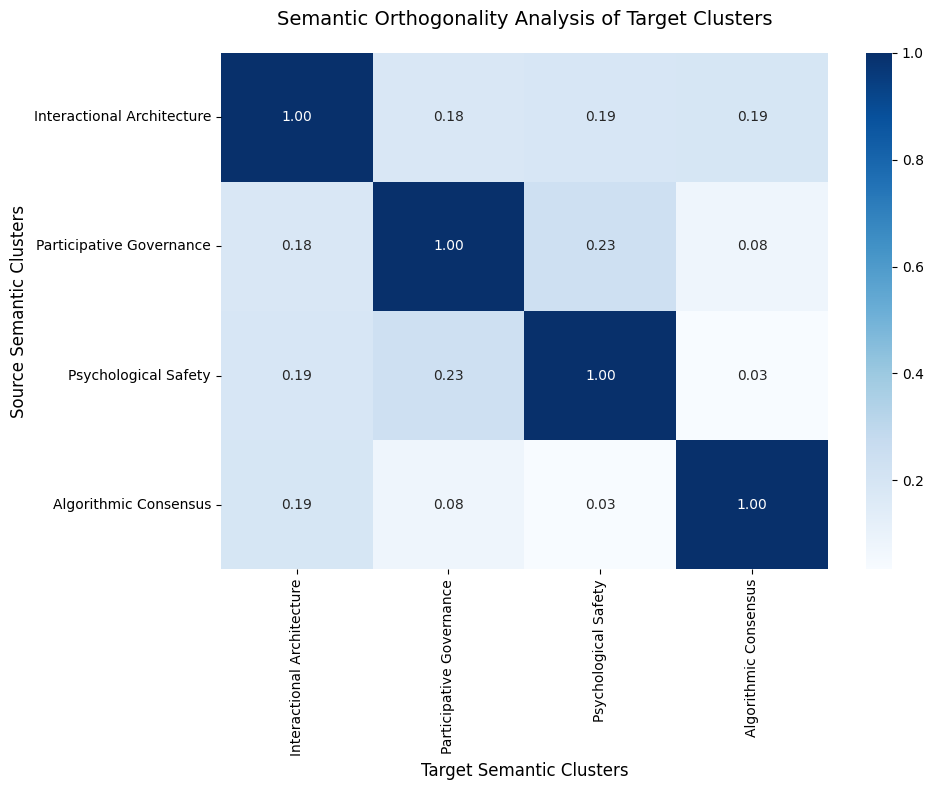

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import userdata
from google import genai

# 1. Setup Gemini Client
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY').split('\r\n')[0].strip()
client = genai.Client(api_key=GEMINI_API_KEY)

# 2. Define Semantic Clusters (As per your DSR logic)
clusters = {
    "cluster1": "Conversational AI agents designed for structured organizational dialogue, multi-turn deliberation, and collective sense-making in workplace settings.",
    "cluster2": "Conversational AI interfaces facilitating employee voice, upward communication, and industrial democracy within hierarchical corporate structures.",
    "cluster3": "Impact of Conversational AI-mediated communication on psychological safety, perceived anonymity, and power-distance during organizational decision-making.",
    "cluster4": "Conversational AI systems for aggregating stakeholder preferences, resolving group conflict, and facilitating consensus through dialogic reasoning."
}

# 3. Preparation: Convert the embedding column to a 2D NumPy matrix for vectorized math
# We assume 'id' and 'embedding' are columns in df_embeddings
print("Preparing embedding matrix...")
all_embeddings = np.stack(df_embeddings['embedding'].values)

def get_gemini_embedding(text):
    """Generates a 768-dim embedding via Gemini API."""
    try:
        response = client.models.embed_content(
            model="gemini-embedding-2",
            contents=text,
            config={"output_dimensionality": 768}
        )
        return np.array(response.embeddings[0].values, dtype=np.float32)
    except Exception as e:
        print(f"Error generating embedding: {e}")
        return None

def get_top_ids_from_df(query_text, k=50):
    """Retrieves top K IDs by calculating Cosine Similarity across the DataFrame."""
    q_vec = get_gemini_embedding(query_text)
    if q_vec is None: return set()

    # Vectorized Cosine Similarity calculation
    # Reshape q_vec to (1, 768) to compare against the matrix
    similarities = cosine_similarity(q_vec.reshape(1, -1), all_embeddings)[0]

    # Get indices of the top K highest similarities
    top_indices = np.argsort(similarities)[::-1][:k]

    # Map indices back to the 'EID' column of your DataFrame (assuming 'EID' is the ID column)
    return set(df_embeddings.iloc[top_indices]['EID'].values)

# 4. Calculate Jaccard Overlap Matrix
labels = list(clusters.keys())
n = len(labels)
matrix = np.zeros((n, n))

print("Executing Cluster Pairwise Retrieval Overlap Analysis...")
sets = {label: get_top_ids_from_df(text, k=200) for label, text in clusters.items()}

for i, l1 in enumerate(labels):
    for j, l2 in enumerate(labels):
        s1, s2 = sets[l1], sets[l2]
        intersection = len(s1.intersection(s2))
        union = len(s1.union(s2))
        matrix[i, j] = intersection / union if union > 0 else 0

# Updated labels for the Heatmap
nice_labels = [
    "Interactional Architecture",
    "Participative Governance",
    "Psychological Safety",
    "Algorithmic Consensus"
]

# 5. Visualization (Q1 Publication Quality)
plt.figure(figsize=(10, 8))

sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=nice_labels, yticklabels=nice_labels)

plt.title("Semantic Orthogonality Analysis of Target Clusters", fontsize=14, pad=20)
plt.xlabel("Target Semantic Clusters", fontsize=12)
plt.ylabel("Source Semantic Clusters", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# @title Researcher Review Threshold

import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

# 1. Pre-calculate Similarity Decay Curves
decay_data = {}
all_embeddings = np.stack(df_embeddings['embedding'].values)

print("Pre-calculating Semantic Decay Curves (HiLAT Calibration)...")

for label, query_text in tqdm(clusters.items()):
    q_vec = get_gemini_embedding(query_text).reshape(1, -1)
    similarities = cosine_similarity(q_vec, all_embeddings)[0]

    temp_df = df_embeddings[['EID', 'Title']].copy()
    temp_df['similarity'] = similarities
    temp_df = temp_df.sort_values(by='similarity', ascending=False).head(200).reset_index(drop=True)
    decay_data[label] = temp_df

# 2. UI Widget Setup
style = {'description_width': 'initial'}

w_cluster = widgets.Dropdown(
    options=list(clusters.keys()),
    description='<b>Target Semantic Cluster:</b>',
    style=style, layout=widgets.Layout(width='450px')
)

w_slider = widgets.IntSlider(
    min=1, max=150, step=1, value=40,
    description='<b>Scan Rank (n):</b>',
    continuous_update=False,
    style=style, layout=widgets.Layout(width='500px')
)

w_stepper = widgets.BoundedIntText(
    min=1, max=150, step=1, value=40,
    description='<b>Rank (n):</b>',
    style=style, layout=widgets.Layout(width='150px')
)

widgets.link((w_slider, 'value'), (w_stepper, 'value'))
output = widgets.Output()

# 3. Dynamic Plotting & Audit Logic
def update_hilat(change=None):
    cluster_name = w_cluster.value
    n_rank = w_slider.value

    df_cluster = decay_data[cluster_name]
    scores = df_cluster['similarity'].values
    cutoff_score = scores[n_rank - 1]

    with output:
        output.clear_output(wait=True)

        # Plotting the Decay Curve
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(range(len(scores)), scores, color='#34495e', linewidth=2.5, label='Semantic Proximity')
        ax.axvline(x=n_rank-1, color='#e74c3c', linestyle='-', linewidth=2, label=f'Truncation Rank (n={n_rank})')
        ax.axhline(y=cutoff_score, color='#27ae60', linestyle='--', alpha=0.6, label=f'Threshold ({cutoff_score:.3f})')
        ax.axvspan(0, n_rank-1, color='#27ae60', alpha=0.1, label='Keep (High Fidelity)')
        ax.axvspan(n_rank-1, len(scores), color='#e74c3c', alpha=0.05, label='Drop (Noise/Drift)')

        ax.set_title(f"HiLAT Boundary Inspection: {cluster_name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Cosine Similarity", fontsize=10)
        ax.set_xlabel("Document Rank", fontsize=10)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.2)
        plt.show()

        # Helper function for pretty table display with specific column widths
        def display_styled_df(df):
            # Applying custom CSS for narrow similarity and wrapped titles
            styled = df.style.set_properties(**{
                'white-space': 'normal',
                'text-align': 'left'
            }).set_table_styles([
                {'selector': 'th.col_heading.level0.col0', 'props': [('width', '80px')]}, # Similarity Header
                {'selector': 'td.col0', 'props': [('width', '80px'), ('font-weight', 'bold')]}, # Similarity Cells
                {'selector': 'td.col1', 'props': [('min-width', '550px')]}, # Title Cells
            ])
            display(HTML(styled.to_html()))

        # CONTEXT PANEL: Show the researcher exactly what they are searching for
        print(f"\n{'='*100}")
        print(f" SEMANTIC ANCHOR CONTEXT: {cluster_name}")
        print(f" \"{clusters[cluster_name]}\"")
        print(f"{'='*100}")

        # AUDIT PANEL
        print(f" BORDER AUDIT: INSPECTING AT RANK {n_rank}")
        print(f"{'='*100}")

        # The Tail (Last 3 Included)
        print(f"\033[1;32m[THE TAIL] Last 3 Documents INCLUDED (Rank {n_rank-2} to {n_rank}):\033[0m")
        tail_df = df_cluster.iloc[max(0, n_rank-3):n_rank][['similarity', 'Title']]
        display_styled_df(tail_df)

        print("\n" + "-"*100)

        # The Drop Zone (First 3 Excluded)
        print(f"\033[1;31m[THE DROP ZONE] First 3 Documents EXCLUDED (Rank {n_rank+1} to {n_rank+3}):\033[0m")
        drop_df = df_cluster.iloc[n_rank:n_rank+3][['similarity', 'Title']]
        display_styled_df(drop_df)
        print(f"{'='*100}")

# 4. Initialize
w_cluster.observe(update_hilat, names='value')
w_slider.observe(update_hilat, names='value')

ui = widgets.VBox([w_cluster, widgets.HBox([w_slider, w_stepper]), output])
update_hilat()
display(ui)

Pre-calculating Semantic Decay Curves (HiLAT Calibration)...


  0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# @title Final Semantic Acquisition
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. INPUT: Your Calibrated Cut-offs (Based on your HiLAT Boundary Inspection)
# These represent the "Semantic Knee" where the high-fidelity literature meets drift.
final_calibration = {
    "cluster1": 42,
    "cluster2": 21,
    "cluster3": 41,
    "cluster4": 51
}

# 2. SETUP: Prepare the Embedding Matrix from your DataFrame
print("Preparing Global Embedding Matrix...")
# We assume df_embeddings has 'embedding' and metadata columns
all_embeddings = np.stack(df_embeddings['embedding'].values)

# --- CITRUS TOOL: APA CITATION GENERATOR ---
def generate_apa_label(row):
    """Constructs a standard citation label for identification."""
    authors = row.get('Authors', 'Unknown')
    year = str(row.get('Year', 'n.d.'))

    if pd.isna(authors) or authors == "Unknown":
        return f"Unknown ({year})"

    author_list = str(authors).split(';')
    if len(author_list) > 1:
        return f"{author_list[0].strip()} et al. ({year})"
    return f"{author_list[0].strip()} ({year})"

print("-- STARTING TARGETED ACQUISITION --")

acquired_data = []

# 3. EXECUTION: Targeted Semantic Harvest
for label, n_cutoff in final_calibration.items():
    if n_cutoff == 0: continue

    # Get query vector for the CAI-centric anchor
    query_text = clusters[label]
    q_vec = get_gemini_embedding(query_text).reshape(1, -1)

    # Vectorized similarity calculation
    similarities = cosine_similarity(q_vec, all_embeddings)[0]

    # Create temporary view to sort and slice
    temp_df = df_embeddings.copy()
    temp_df['Similarity'] = similarities
    temp_df['Cluster_Source'] = label

    # Sort and take exactly the N papers you calibrated in HiLAT
    # Note: Use the actual column names from your df_embeddings (e.g., 'Source title' vs 'Journal')
    top_hits = temp_df.sort_values(by='Similarity', ascending=False).head(n_cutoff)

    acquired_data.append(top_hits)
    print(f"Cluster '{label}': Harvested {n_cutoff} documents at the calibrated boundary.")

# 4. CONSOLIDATION: Merging the Harvest
df_final = pd.concat(acquired_data, ignore_index=True)

# 5. DEDUPLICATION: Cross-Cluster Cleaning
# A paper may semantically reside in more than one cluster (e.g., Governance and Safety)
initial_len = len(df_final)
df_final = df_final.sort_values(by='Similarity', ascending=False)
# Prioritizing the highest similarity occurrence if duplicates exist
df_final = df_final.drop_duplicates(subset=['DOI'], keep='first')

# Apply APA labels
df_final['Citation_Label'] = df_final.apply(generate_apa_label, axis=1)

final_len = len(df_final)

# 6. EXPORT: Final SOTA Candidate List
csv_filename = "citrus_final_sota_candidates.csv"
# Filter to keep essential columns for the review phase
export_cols = ['Similarity', 'Cluster_Source', 'Citation_Label', 'Title', 'Authors', 'Year', 'Source title', 'DOI', 'Abstract']
# Ensure columns exist before exporting (handling potential naming differences)
available_cols = [c for c in export_cols if c in df_final.columns]
df_final[available_cols].to_csv(csv_filename, index=False)

print("\n" + "="*60)
print(f"TOTAL HARVESTED FROM ANCHORS:  {initial_len}")
print(f"UNIQUE CANDIDATES:             {final_len}")
print(f"RECALL GAIN:                   {(final_len / 6) * 100:.1f}% (relative to Lexical n=6)")
print(f"Final list exported to:        {csv_filename}")
print("="*60)

# Display Top 10 High-Fidelity Results
display_cols = ['Similarity', 'Cluster_Source', 'Citation_Label', 'Title']
df_final[display_cols].head(10)

Preparing Global Embedding Matrix...
-- STARTING TARGETED ACQUISITION --
Cluster 'cluster1': Harvested 42 documents at the calibrated boundary.
Cluster 'cluster2': Harvested 21 documents at the calibrated boundary.
Cluster 'cluster3': Harvested 41 documents at the calibrated boundary.
Cluster 'cluster4': Harvested 51 documents at the calibrated boundary.

TOTAL HARVESTED FROM ANCHORS:  155
UNIQUE CANDIDATES:             122
RECALL GAIN:                   2033.3% (relative to Lexical n=6)
Final list exported to:        citrus_final_sota_candidates.csv


,Similarity,Cluster_Source,Citation_Label,Title
63,0.861258,cluster3,Wenting Wang and Rick D. Hackett and Norm Arch...,Will AI-enabled conversational agents acting a...
64,0.857785,cluster3,Izabel Cvetkovic and Imke Grashoff and Ana Jov...,Quid pro Quo: Information disclosure for AI fe...
65,0.855121,cluster3,Marc Becker and David {de Jong} and Roman Brik...,"Using customized, conversational AI agents in ..."
66,0.854422,cluster3,Anand P.A. {van Zelderen} and Sinuo Wu and Ger...,When AI gets Personal: Employee emotional resp...
104,0.850508,cluster4,Triantafyllopoulos L. et al. (2025),From Divergence to Alignment: Evaluating the R...
67,0.849523,cluster3,Lorentsa Gkinko and Amany Elbanna (2023),Designing trust: The formation of employees’ t...
68,0.845914,cluster3,Hung-Yue Suen and Kuo-En Hung (2024),Revealing the influence of AI and its interfac...
69,0.845617,cluster3,Zilong Pan and Ozias A. Moore and Antigoni Pap...,AI literacy and trust: A multi-method study of...
0,0.844980,cluster1,Borghoff U.M. et al. (2025),An organizational theory for multi-agent inter...
70,0.844102,cluster3,Hao X. et al. (2024),Exploring collaborative decision-making: A qua...


In [ ]:
# @title Label identification method

sem_calibrated_df = df_final.copy()
sem_calibrated_df['identification'] = 'semantic'

lex_combined_df = lex_apples_df.copy()
lex_combined_df['identification'] = 'lexical'

# PRISMA Screening

In [ ]:
# @title Combine both identification methods

import pandas as pd

# Combine the two DataFrames. Concatenating retains all records initially, with their source identification.
citrus_df_initial = pd.concat([sem_calibrated_df, lex_combined_df], ignore_index=True)

# Identify unique DOIs and EIDs from the semantic and lexical sets
semantic_dois = set(sem_calibrated_df['DOI'].dropna().unique())
lexical_dois = set(lex_combined_df['DOI'].dropna().unique())
semantic_eids = set(sem_calibrated_df['EID'].dropna().unique())
lexical_eids = set(lex_combined_df['EID'].dropna().unique())

# Find DOIs and EIDs that are common to both original sets
common_dois = semantic_dois.intersection(lexical_dois)
common_eids = semantic_eids.intersection(lexical_eids)

# Function to update identification based on common elements
def update_identification(row):
    if (pd.notna(row['DOI']) and row['DOI'] in common_dois) or \
       (pd.notna(row['EID']) and row['EID'] in common_eids):
        return 'both'
    return row['identification']

# Apply the update function to mark records present in both original sets
citrus_df_initial['identification'] = citrus_df_initial.apply(update_identification, axis=1)

# Now deduplicate. We want to keep the 'both' identified record if available,
# otherwise 'semantic' over 'lexical'.
# To achieve this, we sort by identification (e.g., 'both' first, then 'semantic', then 'lexical')
# and then drop duplicates keeping the first occurrence.
identification_order = {'both': 0, 'semantic': 1, 'lexical': 2}
citrus_df_initial['identification_rank'] = citrus_df_initial['identification'].map(identification_order)

# Sort by identification rank (to prioritize 'both', then 'semantic', then 'lexical')
# and then by Similarity (descending) to keep the higher similarity record for semantic.
# For lexical-only records, Similarity will be NaN and will be placed last due to default na_position='last'.
citrus_df = citrus_df_initial.sort_values(
    by=['identification_rank', 'Similarity'],
    ascending=[True, False]
).copy()

initial_combined_records = len(citrus_df_initial) # This is before final deduplication

# Drop duplicates based on 'DOI' then 'EID', keeping the first (which is prioritized by sorting)
citrus_df.drop_duplicates(subset=['DOI'], keep='first', inplace=True)
citrus_df.drop_duplicates(subset=['EID'], keep='first', inplace=True)

final_count = len(citrus_df)

# Remove the temporary rank column
citrus_df.drop(columns=['identification_rank'], inplace=True)

print(f"Initial combined records (before final deduplication): {initial_combined_records}")
print(f"Unique records after deduplication: {final_count}")
print(f"Effective duplicates removed during final deduplication: {initial_combined_records - final_count}")

print("\nFirst 5 rows of citrus_df:")
display(citrus_df.head())

print("\ncitrus_df info:")
citrus_df.info()

Initial combined records (before final deduplication): 128
Unique records after deduplication: 127
Effective duplicates removed during final deduplication: 1

First 5 rows of canopy_df:


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,Source,EID,norm_title,database,embedding_text,embedding,Similarity,Cluster_Source,Citation_Label,identification
11,Trillo J.R.; González-Quesada J.C.; Cabrerizo ...,"Trillo, José Ramón (57218864635); González-Que...",57218864635; 57926598700; 23089932600; 5875386...,Mitigating Linguistic Aggression in Group Deci...,2026,Evolving Systems,17,2,47,None,...,Scopus,2-s2.0-105034162812,mitigating linguistic aggression in group deci...,Scopus,Title: Mitigating Linguistic Aggression in Gro...,"[0.003000749, 0.011915285, -0.015916053, 7.343...",0.843078,cluster4,Trillo J.R. et al. (2026),both
0,Wenting Wang and Rick D. Hackett and Norm Arch...,None,None,Will AI-enabled conversational agents acting a...,2025,Information & Management,62,2,,104099.0,...,None,WANG2025104099,will ai-enabled conversational agents acting a...,ScienceDirect,Title: Will AI-enabled conversational agents a...,"[-0.0005976601, -0.006279075, -0.01557506, 0.0...",0.861258,cluster3,Wenting Wang and Rick D. Hackett and Norm Arch...,semantic
1,Izabel Cvetkovic and Imke Grashoff and Ana Jov...,None,None,Quid pro Quo: Information disclosure for AI fe...,2025,Computers in Human Behavior: Artificial Humans,4,None,,100137.0,...,None,CVETKOVIC2025100137,quid pro quo: information disclosure for ai fe...,ScienceDirect,Title: Quid pro Quo: Information disclosure fo...,"[0.010689016, -0.007979459, 0.010544895, 0.049...",0.857785,cluster3,Izabel Cvetkovic and Imke Grashoff and Ana Jov...,semantic
2,Marc Becker and David {de Jong} and Roman Brik...,None,None,"Using customized, conversational AI agents in ...",2026,The Leadership Quarterly,37,3,,101952.0,...,None,BECKER2026101952,"using customized, conversational ai agents in ...",ScienceDirect,"Title: Using customized, conversational AI age...","[0.008695322, -0.010648015, 0.007097437, 0.030...",0.855121,cluster3,Marc Becker and David {de Jong} and Roman Brik...,semantic
3,Anand P.A. {van Zelderen} and Sinuo Wu and Ger...,None,None,When AI gets Personal: Employee emotional resp...,2025,Computers in Human Behavior: Artificial Humans,5,None,,100189.0,...,None,VANZELDEREN2025100189,when ai gets personal: employee emotional resp...,ScienceDirect,Title: When AI gets Personal: Employee emotion...,"[0.005435739, 0.0062044, -0.011516989, 0.03830...",0.854422,cluster3,Anand P.A. {van Zelderen} and Sinuo Wu and Ger...,semantic



canopy_df info:
<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 11 to 127
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Authors            127 non-null    object 
 1   Author full names  78 non-null     object 
 2   Author(s) ID       78 non-null     object 
 3   Title              127 non-null    object 
 4   Year               127 non-null    object 
 5   Source title       127 non-null    object 
 6   Volume             117 non-null    object 
 7   Issue              67 non-null     object 
 8   Art. No.           126 non-null    object 
 9   Page start         65 non-null     object 
 10  Page end           65 non-null     object 
 11  Cited by           127 non-null    float64
 12  DOI                127 non-null    object 
 13  Link               127 non-null    object 
 14  Abstract           127 non-null    object 
 15  Author Keywords    120 non-null    object 
 16  Index Keyword

In [ ]:
# @title Save to Google Drive for Screening process

import os

output_excel_filename = 'citrus_df.xlsx'
output_excel_path = os.path.join(file_path, output_excel_filename)

citrus_df.to_excel(output_excel_path, index=False)

print(f"Successfully saved citrus_df to: {output_excel_path}")